In [3]:


import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

print(f"stim      : {stim.__version__}")
print(f"pymatching: {pymatching.__version__}")
print(f"numpy     : {np.__version__}")

stim      : 1.15.0
pymatching: 2.3.1
numpy     : 2.4.3


In [4]:
DISTANCE = 3
ROUNDS   = 3       # standard: rounds = distance
P_PHYS   = 0.01   # physical error rate (1%)

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=ROUNDS,
    distance=DISTANCE,
    after_clifford_depolarization=P_PHYS,
    after_reset_flip_probability=P_PHYS / 10,
    before_measure_flip_probability=P_PHYS / 10,
    before_round_data_depolarization=P_PHYS / 10,
)

print("=== Circuit overview ===")
print(f"  Total qubits    : {circuit.num_qubits}")
print(f"  Data qubits     : {DISTANCE**2} (= d²)")
print(f"  Ancilla qubits  : {DISTANCE**2 - 1} (= d²-1)")
print(f"  Detectors       : {circuit.num_detectors}")
print(f"  Logical observ. : {circuit.num_observables}")
print()
print("=== First 30 instructions ===")
for line in str(circuit).split('\n')[:30]:
    print(" ", line)

=== Circuit overview ===
  Total qubits    : 26
  Data qubits     : 9 (= d²)
  Ancilla qubits  : 8 (= d²-1)
  Detectors       : 24
  Logical observ. : 1

=== First 30 instructions ===
  QUBIT_COORDS(1, 1) 1
  QUBIT_COORDS(2, 0) 2
  QUBIT_COORDS(3, 1) 3
  QUBIT_COORDS(5, 1) 5
  QUBIT_COORDS(1, 3) 8
  QUBIT_COORDS(2, 2) 9
  QUBIT_COORDS(3, 3) 10
  QUBIT_COORDS(4, 2) 11
  QUBIT_COORDS(5, 3) 12
  QUBIT_COORDS(6, 2) 13
  QUBIT_COORDS(0, 4) 14
  QUBIT_COORDS(1, 5) 15
  QUBIT_COORDS(2, 4) 16
  QUBIT_COORDS(3, 5) 17
  QUBIT_COORDS(4, 4) 18
  QUBIT_COORDS(5, 5) 19
  QUBIT_COORDS(4, 6) 25
  R 1 3 5 8 10 12 15 17 19
  X_ERROR(0.001) 1 3 5 8 10 12 15 17 19
  R 2 9 11 13 14 16 18 25
  X_ERROR(0.001) 2 9 11 13 14 16 18 25
  TICK
  DEPOLARIZE1(0.001) 1 3 5 8 10 12 15 17 19
  H 2 11 16 25
  DEPOLARIZE1(0.01) 2 11 16 25
  TICK
  CX 2 3 16 17 11 12 15 14 10 9 19 18
  DEPOLARIZE2(0.01) 2 3 16 17 11 12 15 14 10 9 19 18
  TICK
  CX 2 1 16 15 11 10 8 14 3 9 12 18


In [5]:
# Extract qubit coordinates for visualization
qubit_coords = {}
for inst in circuit.flattened():
    if inst.name == 'QUBIT_COORDS':
        x, y = inst.gate_args_copy()
        q = inst.targets_copy()[0].value
        qubit_coords[q] = (x, y)

print(f"Qubits with coordinates: {len(qubit_coords)}")
print("Sample entries:")
for q, (x,y) in list(qubit_coords.items())[:6]:
    print(f"  qubit {q:2d} → ({x}, {y})")

Qubits with coordinates: 17
Sample entries:
  qubit  1 → (1.0, 1.0)
  qubit  2 → (2.0, 0.0)
  qubit  3 → (3.0, 1.0)
  qubit  5 → (5.0, 1.0)
  qubit  8 → (1.0, 3.0)
  qubit  9 → (2.0, 2.0)


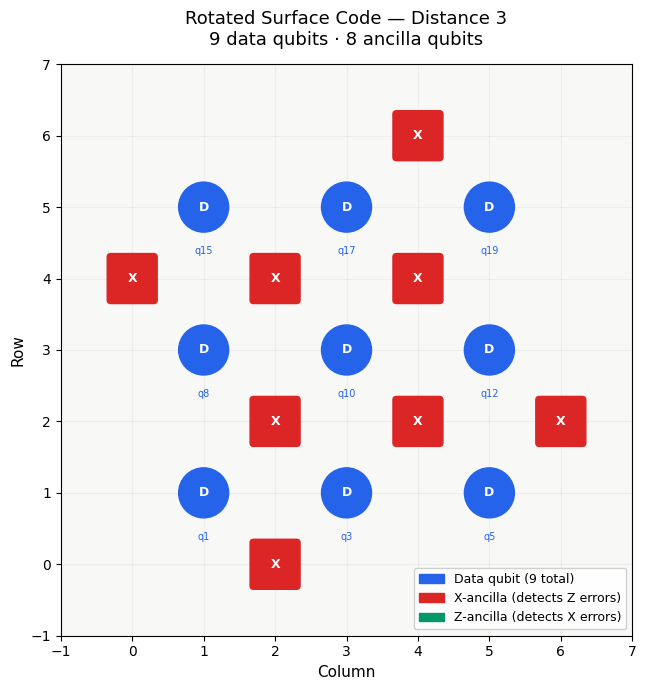

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19
X_ERROR(0.001) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.001) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.001) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.01) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.01) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.01) 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.01) 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
DEPOLARIZE2(0.01) 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
DEPOLARIZE1(0.01) 2 11 16 25
TICK
X_ERROR

In [7]:
def plot_surface_code_layout(circuit, distance):
    """Plot the rotated surface code qubit layout."""
    # Parse qubit coordinates
    qubit_coords = {}
    for inst in circuit.flattened():
        if inst.name == 'QUBIT_COORDS':
            x, y = inst.gate_args_copy()
            q = inst.targets_copy()[0].value
            qubit_coords[q] = (x, y)

    # Identify data vs ancilla qubits
    # In rotated surface code: data qubits have integer coords summing to even
    # ancilla qubits have coords summing to odd
    data_qubits    = {q: c for q, c in qubit_coords.items() if (c[0]+c[1]) % 2 == 0 and c[0]%2==1}
    x_ancillas     = {q: c for q, c in qubit_coords.items() if (c[0]+c[1]) % 2 == 0 and c[0]%2==0 and c[1]%2==0}
    z_ancillas     = {q: c for q, c in qubit_coords.items() if (c[0]+c[1]) % 2 == 1}

    # Fallback: classify by coordinate parity
    data_q   = {q: c for q, c in qubit_coords.items() if int(c[0]) % 2 == 1 and int(c[1]) % 2 == 1}
    anc_q    = {q: c for q, c in qubit_coords.items() if q not in data_q}
    # X ancillas: even row, Z ancillas: odd row (approximate heuristic)
    x_anc = {q: c for q, c in anc_q.items() if int(c[1]) % 2 == 0}
    z_anc = {q: c for q, c in anc_q.items() if int(c[1]) % 2 == 1}

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.set_aspect('equal')
    ax.set_facecolor('#f8f8f6')
    fig.patch.set_facecolor('#ffffff')

    # Draw data qubits
    for q, (x, y) in data_q.items():
        circle = plt.Circle((x, y), 0.35, color='#2563EB', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, f'D', ha='center', va='center', fontsize=9,
                color='white', fontweight='bold', zorder=4)
        ax.text(x+0.0, y-0.55, f'q{q}', ha='center', va='top', fontsize=7,
                color='#2563EB')

    # Draw X ancillas
    for q, (x, y) in x_anc.items():
        sq = mpatches.FancyBboxPatch((x-0.3, y-0.3), 0.6, 0.6,
            boxstyle="round,pad=0.05", color='#DC2626', zorder=3)
        ax.add_patch(sq)
        ax.text(x, y, 'X', ha='center', va='center', fontsize=9,
                color='white', fontweight='bold', zorder=4)

    # Draw Z ancillas
    for q, (x, y) in z_anc.items():
        sq = mpatches.FancyBboxPatch((x-0.3, y-0.3), 0.6, 0.6,
            boxstyle="round,pad=0.05", color='#059669', zorder=3)
        ax.add_patch(sq)
        ax.text(x, y, 'Z', ha='center', va='center', fontsize=9,
                color='white', fontweight='bold', zorder=4)

    # Grid lines
    all_x = [c[0] for c in qubit_coords.values()]
    all_y = [c[1] for c in qubit_coords.values()]
    ax.set_xlim(min(all_x)-1, max(all_x)+1)
    ax.set_ylim(min(all_y)-1, max(all_y)+1)
    ax.set_xlabel('Column', fontsize=11)
    ax.set_ylabel('Row', fontsize=11)
    ax.set_title(f'Rotated Surface Code — Distance {distance}\n'
                 f'{distance**2} data qubits · {distance**2-1} ancilla qubits',
                 fontsize=13, pad=14)
    ax.grid(True, alpha=0.15, zorder=0)

    # Legend
    legend_elements = [
        mpatches.Patch(color='#2563EB', label=f'Data qubit ({distance**2} total)'),
        mpatches.Patch(color='#DC2626', label='X-ancilla (detects Z errors)'),
        mpatches.Patch(color='#059669', label='Z-ancilla (detects X errors)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
              framealpha=0.9)
    plt.tight_layout()
    plt.show()

plot_surface_code_layout(circuit, DISTANCE)
print(circuit)